# Md. Reahoon Zannah (ID: 223002038)
## Naieve Bayes IMDB sentiment prediction

In [28]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [29]:
# recognize unnecsesary word using 'stopword'

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
print(list(stop_words)[:20])

["he'll", 'doing', 'or', 's', "wouldn't", 'your', 'too', "weren't", 'y', 'but', 'about', "we've", 'as', 'there', 'whom', 'into', 'few', 'weren', 'during', 'are']


In [30]:
# Text Cleaning Function
# import re

def clean_text(text):
    text = text.lower()   # lowercase
    text = re.sub(r'<.*?>', '', text)   # remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)   # remove punctuation & numbers
    words = text.split()   # tokenization
    words = [w for w in words if w not in stop_words]   # remove stopwords
    return " ".join(words)

In [31]:
# find path

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [32]:
# Cleaning Apply

df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

df['clean_review'] = df['review'].apply(clean_text)
df.head()


# data pre processing done

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [33]:
# text to number: frequency

from sklearn.feature_extraction.text import CountVectorizer
#vectorizer = CountVectorizer() # all column
vectorizer = CountVectorizer(max_features=5000) # 5000 column
X = vectorizer.fit_transform(df['clean_review'])


# level encoder for (+ -)

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(df['sentiment'])

In [34]:
#Word Frequency Matrix

doc_array = vectorizer.transform(df['clean_review']).toarray()
print(doc_array)


#Pandas DataFrame

print('\nPandas DataFrame:\n')
frequency_matrix = pd.DataFrame(
    doc_array,
    columns=vectorizer.get_feature_names_out()
)

frequency_matrix.head()

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Pandas DataFrame:



,aaron,abandoned,abc,abilities,ability,able,absence,absent,absolute,absolutely,...,yesterday,yet,york,young,younger,youth,zero,zombie,zombies,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [35]:
# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% dataset for training
    random_state=42
)


# train naive bayes

from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [36]:
# prediction + accuracy

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8524
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.86      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



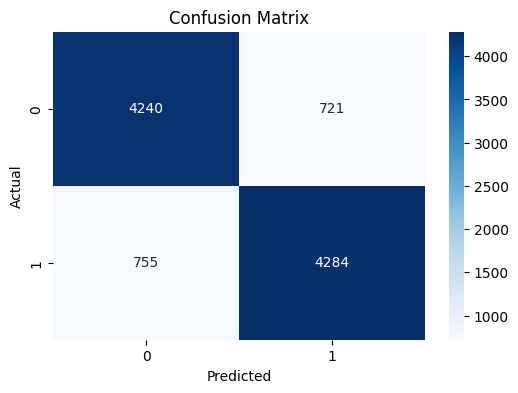

In [37]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

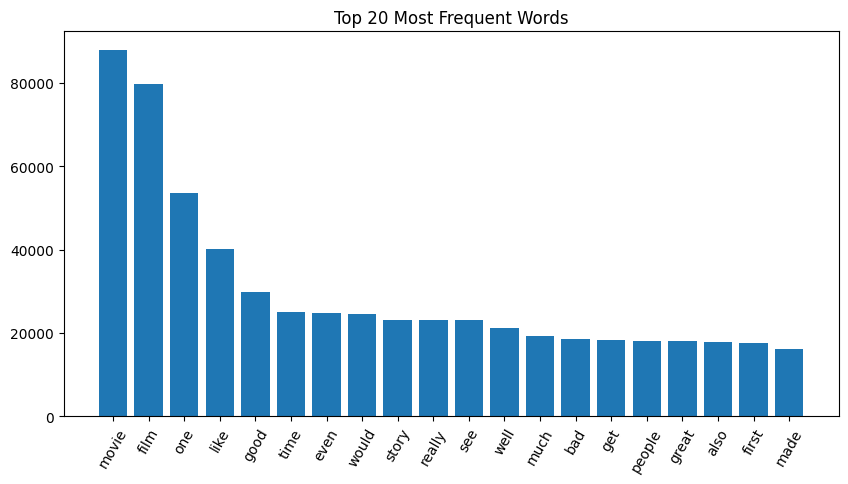

In [38]:
# Top Most Frequent Word

sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:20]
words = [w[0] for w in words_freq]
freq = [w[1] for w in words_freq]

plt.figure(figsize=(10,5))
plt.bar(words, freq)
plt.xticks(rotation=60)
plt.title("Top 20 Most Frequent Words")
plt.show()

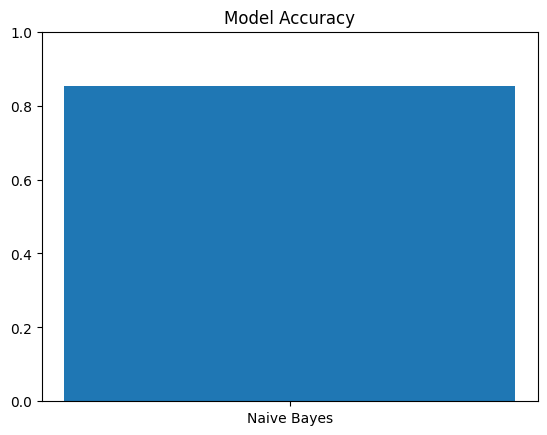

In [39]:
# Accuracy Visualization

accuracy = accuracy_score(y_test, y_pred)

plt.bar(["Naive Bayes"], [accuracy])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.show()